<img src="https://github.com/mariabda2/intro_data_2026/blob/main/sesiones_practicas/imgs/banner_fcd.jpg?raw=1" alt="bannersp" width="1100"  height="150">

# <span style="color:#2F749F;"><strong>📦 Sesión práctica 3: Codificación y transformación de variables</strong></span>
---
<p align="right">
  <a href="https://github.com/mariabda2/intro_data_2026/blob/main/sesiones_practicas/sp_3_maria_bernarda_salazar.ipynb?clone=true" target="_blank">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/>
  </a>
</p>


## <span style="color:black;"><strong>Datos del estudiante</strong></span>

David Felipe Tovar Zurita | Jhon Alejandro García Pareja

# <span style="color:#2F749F;"><strong>Ejercicio 1: Comparación de métodos de escalamiento</strong></span>

A partir de un conjunto de datos real sobre **vinos**, analiza cómo cambia la escala de las variables al aplicar diferentes métodos de **escalamiento de datos**, y compara visualmente sus efectos sobre la distribución.

1. Carga el conjunto de datos **wine** desde la librería `sklearn.datasets` usando `load_wine()`.

2. Convierte el conjunto de datos en un **DataFrame de pandas** e identifica las variables disponibles.

3. Selecciona al menos **tres variables numéricas** para el análisis (por ejemplo):
   - `alcohol`
   - `malic_acid`
   - `color_intensity`

4. Aplica los siguientes métodos de escalamiento sobre las variables seleccionadas:
   - `StandardScaler`
   - `MinMaxScaler`
   - `RobustScaler`
   - `Z-Score`

5. Genera **gráficas comparativas** que permitan visualizar la distribución de al menos **una de las variables seleccionadas** en los siguientes escenarios:
   - Distribución **original**
   - Distribución con **StandardScaler**
   - Distribución con **MinMaxScaler**
   - Distribución con **RobustScaler**
   - Distribución con **Z-Score**

6. Escribe un análisis de **máximo cinco líneas** en el que expliques las diferencias entre las técnicas o métodos, su impacto en los resultados y cuál consideras más recomendable, justificando brevemente tu elección.

## **1. Cargar el conjunto**

In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_wine

wine = load_wine()

## **2. DataFrame**

In [2]:
# Crear DataFrame con las características
df = pd.DataFrame(wine.data, columns=wine.feature_names)

# Ver las primeras filas
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


## **3. Selección de variables numéricas**

* **Alcohol** – Porcentaje de alcohol en el vino.
* **Ash** – Ceniza total.
* **Alcalinity_of_ash** Alcalinidad de la ceniza.

In [4]:
variables = ['alcohol', 'ash', 'alcalinity_of_ash']
df_sel = df[variables].copy()

print("=" * 50)
print("DATOS ORIGINALES - Resultado")
print("=" * 50)
print(df_sel.head(10))
print("\nEstadísticas:")
print(df_sel.describe().round(4))

DATOS ORIGINALES - Resultado
   alcohol   ash  alcalinity_of_ash
0    14.23  2.43               15.6
1    13.20  2.14               11.2
2    13.16  2.67               18.6
3    14.37  2.50               16.8
4    13.24  2.87               21.0
5    14.20  2.45               15.2
6    14.39  2.45               14.6
7    14.06  2.61               17.6
8    14.83  2.17               14.0
9    13.86  2.27               16.0

Estadísticas:
        alcohol       ash  alcalinity_of_ash
count  178.0000  178.0000           178.0000
mean    13.0006    2.3665            19.4949
std      0.8118    0.2743             3.3396
min     11.0300    1.3600            10.6000
25%     12.3625    2.2100            17.2000
50%     13.0500    2.3600            19.5000
75%     13.6775    2.5575            21.5000
max     14.8300    3.2300            30.0000


**Interpretación:**
Según las estadísticas, las variables tienen comportamientos distintos. alcohol tiene valores más altos y una dispersión mayor, mientras que ash se mantiene en un rango mucho más pequeño. alcalinity_of_ash muestra valores intermedios pero con variación más amplia. Esto deja ver que los datos no están en la misma escala y que hay diferencias claras en la distribución, lo que hace necesario aplicar escalamiento.

##**4. Métodos de escalamiento**

###**StandardScaler**

In [5]:
from sklearn.preprocessing import StandardScaler
from IPython.display import display

ss = StandardScaler()
df_standard = pd.DataFrame(ss.fit_transform(df_sel), columns=variables)

print("=" * 50)
print("STANDARD SCALER - Resultado")
print("=" * 50)
display(df_standard.head(10))
print("\nEstadísticas:")
display(df_standard.describe().round(4))

STANDARD SCALER - Resultado


,alcohol,ash,alcalinity_of_ash
0,1.518613,0.232053,-1.169593
1,0.246290,-0.827996,-2.490847
2,0.196879,1.109334,-0.268738
3,1.691550,0.487926,-0.809251
4,0.295700,1.840403,0.451946
5,1.481555,0.305159,-1.289707
6,1.716255,0.305159,-1.469878
7,1.308617,0.890014,-0.569023
8,2.259772,-0.718336,-1.650049
9,1.061565,-0.352802,-1.049479



Estadísticas:


,alcohol,ash,alcalinity_of_ash
count,178.0000,178.0000,178.0000
mean,-0.0000,-0.0000,-0.0000
std,1.0028,1.0028,1.0028
min,-2.4342,-3.6792,-2.6710
25%,-0.7882,-0.5721,-0.6891
50%,0.0610,-0.0238,0.0015
75%,0.8361,0.6981,0.6021
max,2.2598,3.1563,3.1545


**Interpretación:**
Aquí se ve que la media queda en 0 y la desviación en 1 en todas las variables, es decir quelas “normaliza”. Pero mirando los valores mínimos y máximos, siguen siendo bastante separados, entonces los extremos siguen influyendo.

###**MinMaxScaler**

In [6]:
from sklearn.preprocessing import MinMaxScaler

mms = MinMaxScaler()
df_minmax = pd.DataFrame(mms.fit_transform(df_sel), columns=variables)

print("=" * 50)
print("MINMAX SCALER - Resultado")
print("=" * 50)
display(df_minmax.head(10))
print("\nEstadísticas:")
display(df_minmax.describe().round(4))

MINMAX SCALER - Resultado


,alcohol,ash,alcalinity_of_ash
0,0.842105,0.572193,0.257732
1,0.571053,0.417112,0.030928
2,0.560526,0.700535,0.412371
3,0.878947,0.609626,0.319588
4,0.581579,0.807487,0.536082
5,0.834211,0.582888,0.237113
6,0.884211,0.582888,0.206186
7,0.797368,0.668449,0.360825
8,1.000000,0.433155,0.175258
9,0.744737,0.486631,0.278351



Estadísticas:


,alcohol,ash,alcalinity_of_ash
count,178.0000,178.0000,178.0000
mean,0.5186,0.5382,0.4585
std,0.2136,0.1467,0.1721
min,0.0000,0.0000,0.0000
25%,0.3507,0.4545,0.3402
50%,0.5316,0.5348,0.4588
75%,0.6967,0.6404,0.5619
max,1.0000,1.0000,1.0000


**Interpretación:**
Todo queda entre 0 y 1, en las estadísticas se evidencia esto. Sin embargo hayq que tener en cuenta que si hay valores muy grandes o pequeños todo se va a ajusta a eso, entonces puede aplastar un poco los demás datos.

###**RobustScaler**


In [7]:
from sklearn.preprocessing import RobustScaler

rs = RobustScaler()
df_robust = pd.DataFrame(rs.fit_transform(df_sel), columns=variables)

print("=" * 50)
print("ROBUST SCALER - Resultado")
print("=" * 50)
display(df_robust.head(10))
print("\nEstadísticas:")
display(df_robust.describe().round(4))

ROBUST SCALER - Resultado


,alcohol,ash,alcalinity_of_ash
0,0.897338,0.201439,-0.906977
1,0.114068,-0.633094,-1.930233
2,0.083650,0.892086,-0.209302
3,1.003802,0.402878,-0.627907
4,0.144487,1.467626,0.348837
5,0.874525,0.258993,-1.000000
6,1.019011,0.258993,-1.139535
7,0.768061,0.719424,-0.441860
8,1.353612,-0.546763,-1.279070
9,0.615970,-0.258993,-0.813953



Estadísticas:


,alcohol,ash,alcalinity_of_ash
count,178.0000,178.0000,178.0000
mean,-0.0376,0.0188,-0.0012
std,0.6174,0.7895,0.7766
min,-1.5361,-2.8777,-2.0698
25%,-0.5228,-0.4317,-0.5349
50%,0.0000,0.0000,0.0000
75%,0.4772,0.5683,0.4651
max,1.3536,2.5036,2.4419


**Interpretación:**
En las estadísticas no hay valores tan extremos como en StandardScaler. Se nota que no le afectan tanto los outliers, porque trabaja con la mediana. Los datos quedan más centrados sin exagerar tanto los extremos.

###**Z-Score**

In [8]:
df_zscore = (df_sel - df_sel.mean()) / df_sel.std()

print("=" * 50)
print("Z-SCORE - Resultado")
print("=" * 50)
display(df_zscore.head(10))
print("\nEstadísticas:")
display(df_zscore.describe().round(4))

Z-SCORE - Resultado


,alcohol,ash,alcalinity_of_ash
0,1.514341,0.231400,-1.166303
1,0.245597,-0.825667,-2.483841
2,0.196325,1.106214,-0.267982
3,1.686791,0.486554,-0.806975
4,0.294868,1.835226,0.450674
5,1.477387,0.304301,-1.286079
6,1.711427,0.304301,-1.465743
7,1.304936,0.887510,-0.567423
8,2.253415,-0.716315,-1.645408
9,1.058578,-0.351810,-1.046527



Estadísticas:


,alcohol,ash,alcalinity_of_ash
count,178.0000,178.0000,178.0000
mean,-0.0000,-0.0000,-0.0000
std,1.0000,1.0000,1.0000
min,-2.4274,-3.6688,-2.6635
25%,-0.7860,-0.5705,-0.6872
50%,0.0608,-0.0238,0.0015
75%,0.8338,0.6961,0.6004
max,2.2534,3.1474,3.1456


**Interpretación:**
Este método es muy parecido a StandardScaler. Al ver las estadísticas, la media queda en 0 y la desviación en 1, al investigar me encuentro que los métodos tienen la misma idea de escalamiento.

##**Gráficas comparativas**

Variable seleccionada **ALCOHOL**.

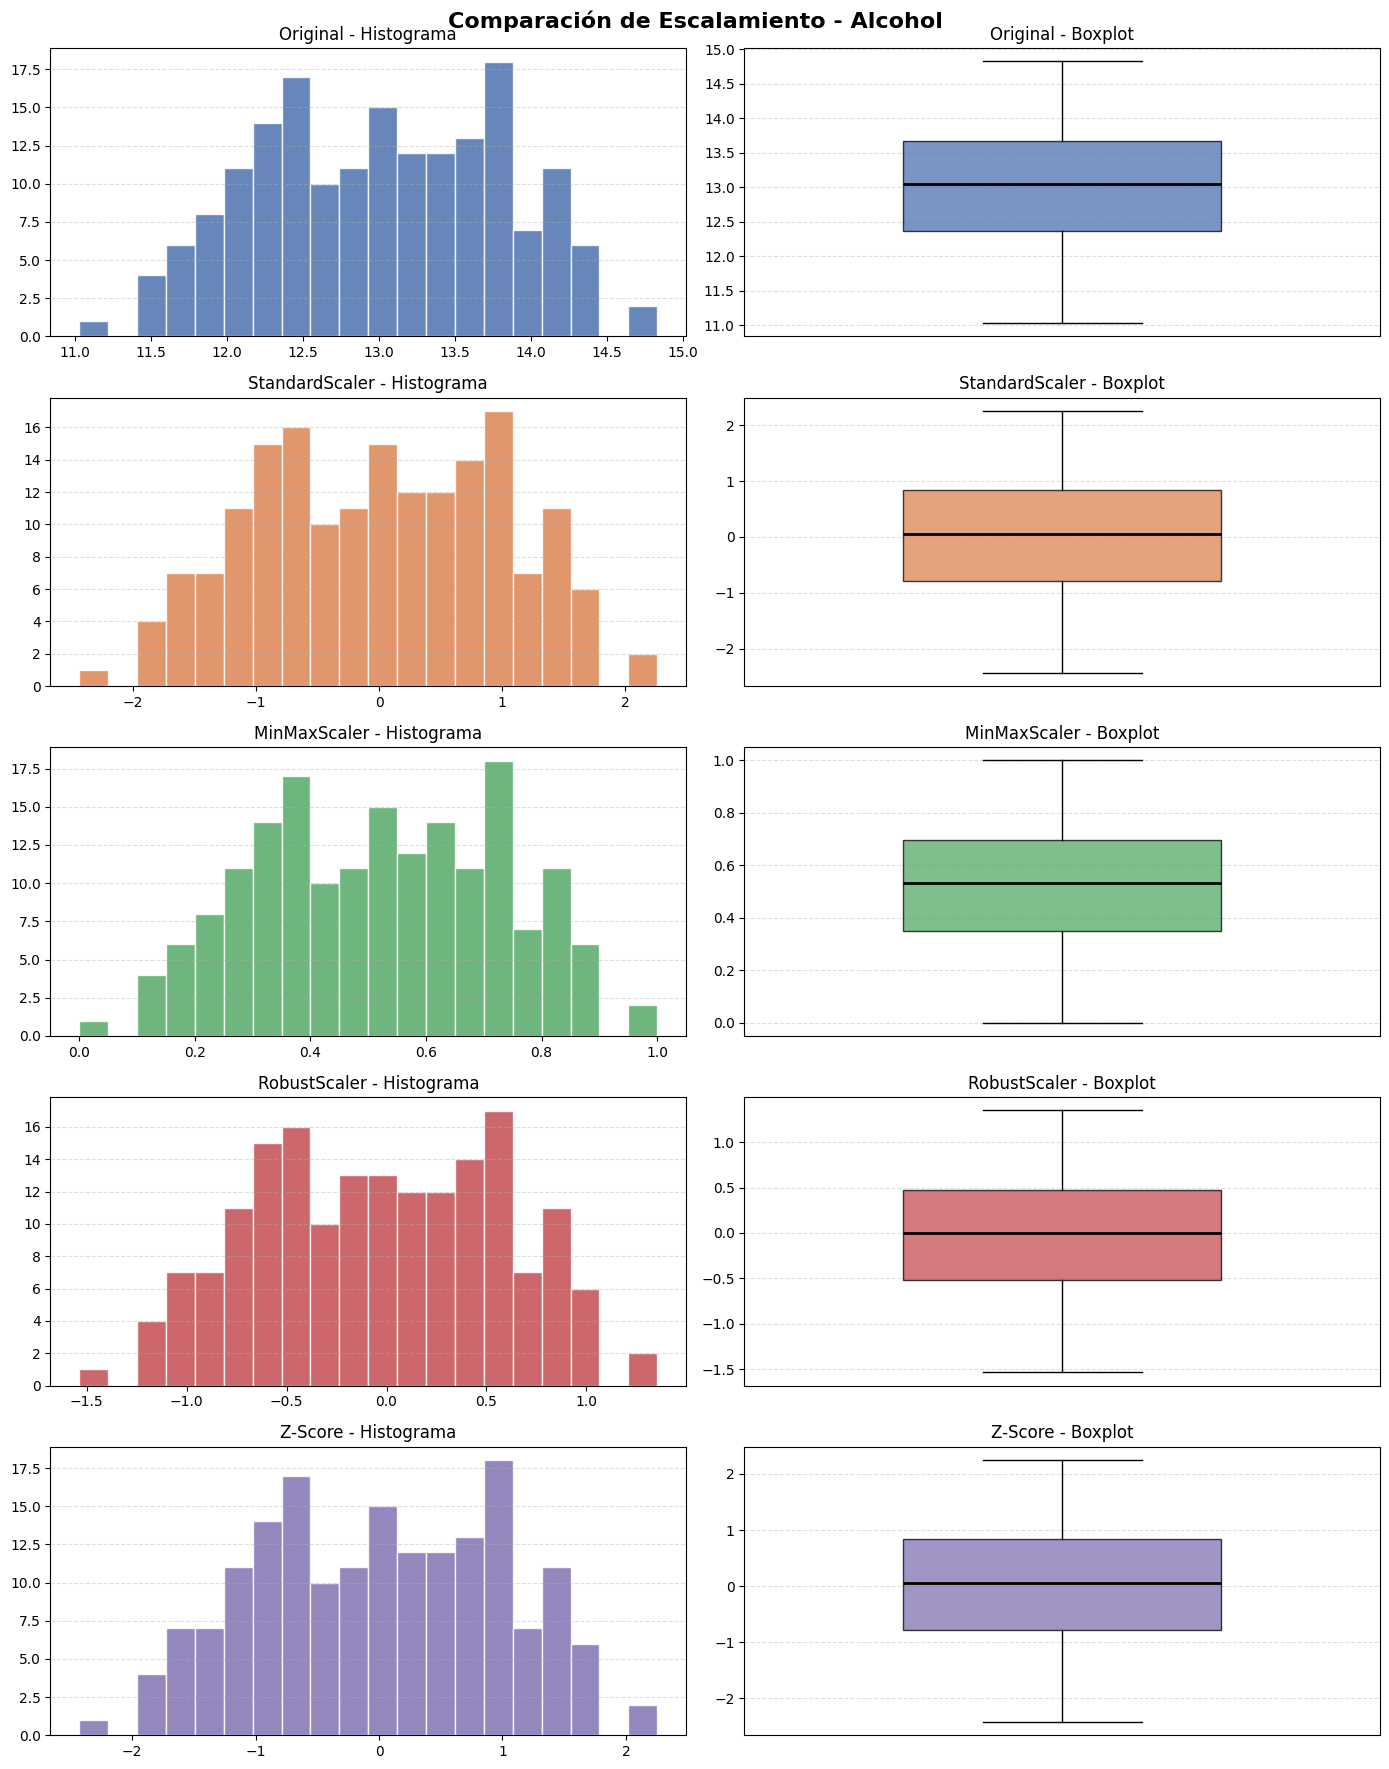

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(5, 2, figsize=(14, 18))
fig.suptitle('Comparación de Escalamiento - Alcohol', fontsize=16, fontweight='bold')

datasets = [
    (df_sel['alcohol'], 'Original', '#4C72B0'),
    (df_standard['alcohol'], 'StandardScaler', '#DD8452'),
    (df_minmax['alcohol'], 'MinMaxScaler', '#55A868'),
    (df_robust['alcohol'], 'RobustScaler', '#C44E52'),
    (df_zscore['alcohol'], 'Z-Score', '#8172B2')
]

for i, (data, title, color) in enumerate(datasets):
    # Histograma
    axes[i, 0].hist(data, bins=20, color=color, edgecolor='white', alpha=0.85)
    axes[i, 0].set_title(f'{title} - Histograma')
    axes[i, 0].grid(axis='y', linestyle='--', alpha=0.4)

    # Boxplot
    bp = axes[i, 1].boxplot(data, patch_artist=True, widths=0.5,
                           medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor(color)
    bp['boxes'][0].set_alpha(0.75)
    axes[i, 1].set_title(f'{title} - Boxplot')
    axes[i, 1].set_xticks([])
    axes[i, 1].grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

##**6. Interpretación**

Los métodos de escalamiento cambian la escala pero no la forma general de la distribución, lo cual se ve en los histogramas. MinMax deja todos los valores entre 0 y 1 y comprime los datos, especialmente cuando hay valores extremos. StandardScaler y Z-Score centran los datos en 0, pero en los boxplots se siguen viendo valores alejados. RobustScaler mantiene mejor la forma sin dejar que los outliers afecten tanto. Por eso, me parece más confiable cuando hay datos extremos.

# <span style="color:#2F749F;"><strong>Ejercicio 2: Comparación de escalamiento RobustScaler vs Z-Score</strong></span>

A partir de un conjunto de datos real sobre **diabetes**, analiza cómo cambia la escala de las variables al aplicar **estandarización con Z-Score** y **escalamiento robusto**, y compara visualmente sus efectos cuando existen **posibles valores atípicos**.

1. Carga el conjunto de datos **diabetes** desde la librería `sklearn.datasets` usando `load_diabetes()`.

2. Convierte el conjunto de datos en un **DataFrame de pandas** e identifica las variables disponibles.

3. Selecciona al menos **tres variables numéricas** para el análisis (por ejemplo: `bmi`, `bp`, `s5` u otras disponibles en el dataset).

4. Aplica los siguientes métodos de escalamiento sobre las variables seleccionadas:
   - **StandardScaler** (Z-Score).
   - **RobustScaler** (basado en mediana e IQR).

5. Genera **gráficas comparativas** que permitan visualizar la distribución de al menos **una de las variables seleccionadas** en los siguientes escenarios:
   - Distribución **original**
   - Distribución **escalada con Z-Score**
   - Distribución **escalada con RobustScaler**

6. Escribe un análisis de **máximo cinco líneas** en el que expliques las diferencias entre las técnicas o métodos, su impacto en los resultados y cuál consideras más recomendable, justificando brevemente tu elección.

###**1. Carga de datos**

In [10]:
from sklearn.datasets import load_diabetes

# Cargar dataset
diabetes = load_diabetes()

###**2. Data Frame e Identificacion de variables.**

In [11]:
import pandas as pd

# Crear DataFrame con las variables
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)

# Agregar la variable objetivo (target)
df["target"] = diabetes.target

df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [4]:
print(df.columns)

Index(['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6',
       'target'],
      dtype='object')


###**3. Selección de variables númericas**

Se seleccionarán las variables ***"bmi", "bp" y "s5"***

In [45]:
print("=" * 50)
print("DATOS ORIGINALES - VARIABLES SELECCIONADAS")
print("=" * 50)

print(df_selected.head(10))

print("\nEstadísticas:")
print(df_selected.describe().round(4))

DATOS ORIGINALES - VARIABLES SELECCIONADAS
   MedInc  AveRooms  HouseAge
0  8.3252  6.984127      41.0
1  8.3014  6.238137      21.0
2  7.2574  8.288136      52.0
3  5.6431  5.817352      52.0
4  3.8462  6.281853      52.0
5  4.0368  4.761658      52.0
6  3.6591  4.931907      52.0
7  3.1200  4.797527      52.0
8  2.0804  4.294118      42.0
9  3.6912  4.970588      52.0

Estadísticas:
           MedInc    AveRooms    HouseAge
count  20640.0000  20640.0000  20640.0000
mean       3.8707      5.4290     28.6395
std        1.8998      2.4742     12.5856
min        0.4999      0.8462      1.0000
25%        2.5634      4.4407     18.0000
50%        3.5348      5.2291     29.0000
75%        4.7432      6.0524     37.0000
max       15.0001    141.9091     52.0000


**Interpretación:**
En las estadísticas de las variables bmi, bp y s5 se observa que presentan diferentes rangos y niveles de dispersión. Algunas tienen valores más concentrados mientras que otras muestran mayor variabilidad, lo que evidencia que no están en la misma escala y dificulta su comparación directa.

###**4. Métodos de escalamiento**

####**StandardScaler (Z-Score)**

In [41]:
print("=" * 50)
print("DATOS ESCALADOS - Z-SCORE")
print("=" * 50)

print(df_zscore.head(10))

print("\nEstadísticas:")
print(df_zscore.describe().round(4))

DATOS ESCALADOS - Z-SCORE
        bmi        bp        s5
0  1.297088  0.459841  0.418531
1 -1.082180 -0.553505 -1.436589
2  0.934533 -0.119214  0.060156
3 -0.243771 -0.770650  0.476983
4 -0.764944  0.459841 -0.672502
5 -0.855583 -0.408741 -0.865679
6 -0.991541 -0.336359 -1.322752
7 -0.039834  1.400804 -0.752992
8  1.297088 -0.843032 -0.314510
9  0.821235 -0.698268  1.424090

Estadísticas:
            bmi        bp        s5
count  442.0000  442.0000  442.0000
mean     0.0000   -0.0000    0.0000
std      1.0011    1.0011    1.0011
min     -1.8979   -2.3630   -2.6510
25%     -0.7196   -0.7706   -0.6989
50%     -0.1531   -0.1192   -0.0409
75%      0.6570    0.7494    0.6819
max      3.5857    2.7761    2.8087


**Interpretación:**
Después de aplicar este método, las estadísticas muestran que la media queda en 0 y la desviación estándar en 1. Esto indica que los datos se centran y se estandarizan, pero siguen siendo sensibles a valores atípicos como lo muestra su minímo y máximo.

####**RobustScaler (basado en mediana e IQR)**

In [40]:
print("=" * 50)
print("DATOS ESCALADOS - RobustScaler")
print("=" * 50)

print(df_robust.head(10))

print("\nEstadísticas:")
print(df_robust.describe().round(4))

DATOS ESCALADOS - RobustScaler
        bmi        bp        s5
0  1.053498  0.380952  0.332755
1 -0.674897 -0.285714 -1.010756
2  0.790123  0.000000  0.073213
3 -0.065844 -0.428571  0.375087
4 -0.444444  0.380952 -0.457391
5 -0.510288 -0.190476 -0.597294
6 -0.609053 -0.142857 -0.928314
7  0.082305  1.000000 -0.515684
8  1.053498 -0.476190 -0.198126
9  0.707819 -0.380952  1.060999

Estadísticas:
            bmi        bp        s5
count  442.0000  442.0000  442.0000
mean     0.1112    0.0784    0.0296
std      0.7273    0.6586    0.7250
min     -1.2675   -1.4762   -1.8903
25%     -0.4115   -0.4286   -0.4765
50%      0.0000    0.0000   -0.0000
75%      0.5885    0.5714    0.5235
max      2.7160    1.9048    2.0638


**Interpretación:**
En este caso, las estadísticas muestran que la mediana queda en 0 y los datos se escalan con el rango intercuartílico. Se nota que este método no se ve tan afectado por valores extremos, por lo que es más estable.

###**5. Gráficas Comparativas**

Variable seleccionada ***"bmi"***.

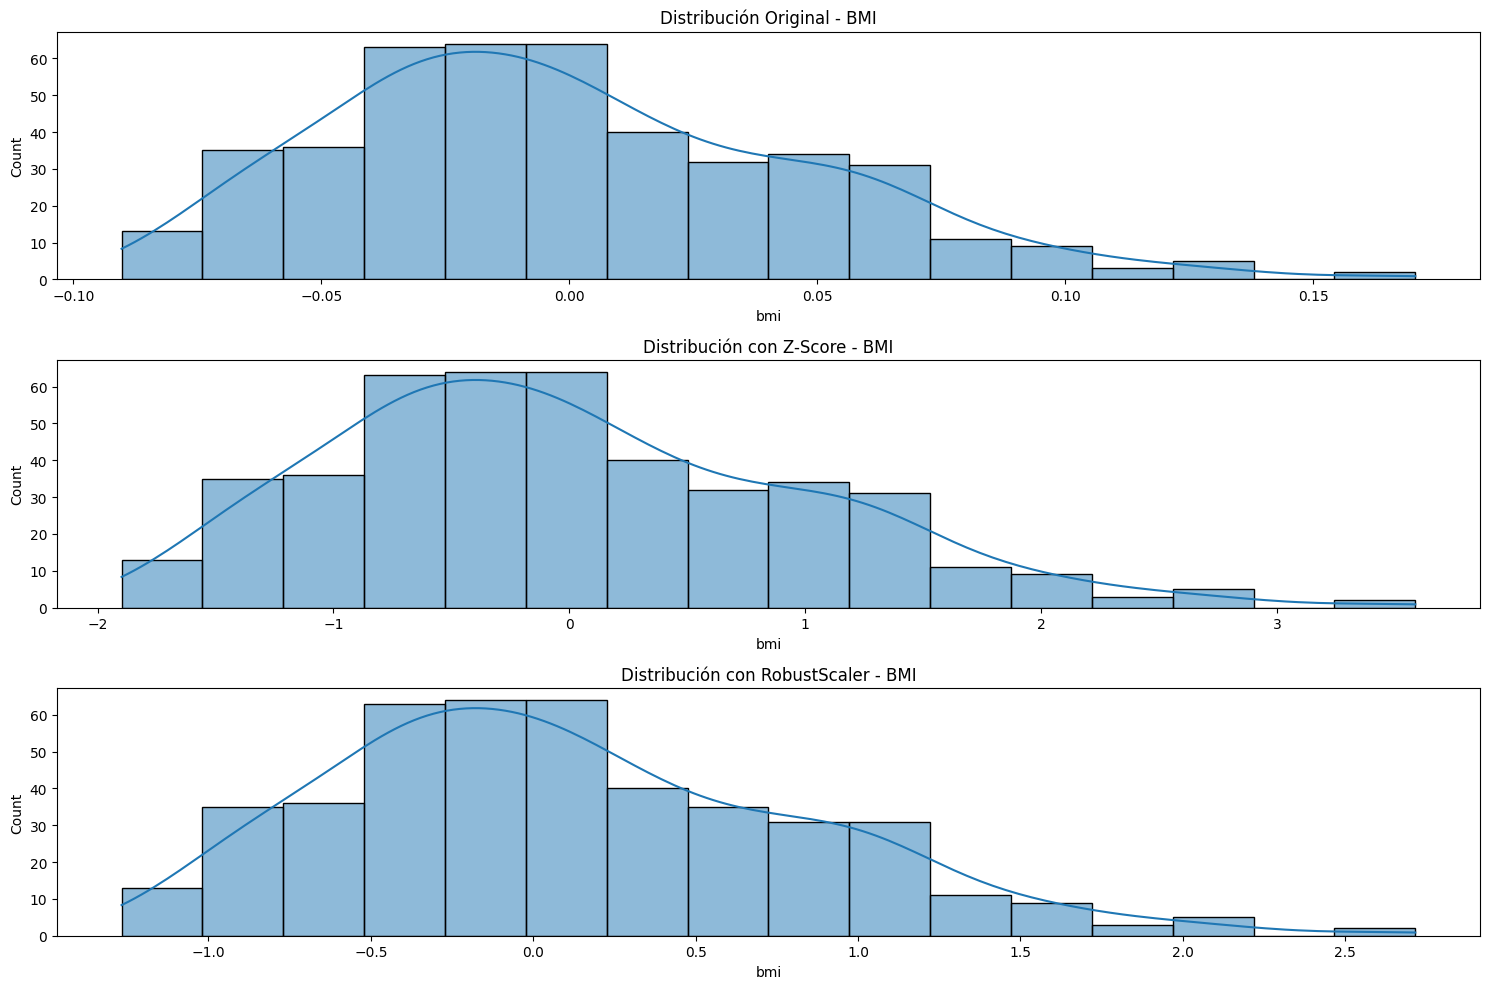

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,10))

# Original
plt.subplot(3,1,1)
sns.histplot(df_selected["bmi"], kde=True)
plt.title("Distribución Original - BMI")

# Z-Score
plt.subplot(3,1,2)
sns.histplot(df_zscore["bmi"], kde=True)
plt.title("Distribución con Z-Score - BMI")

# RobustScaler
plt.subplot(3,1,3)
sns.histplot(df_robust["bmi"], kde=True)
plt.title("Distribución con RobustScaler - BMI")

plt.tight_layout()
plt.show()

###**6. Interpretación**
El Z-Score estandariza los datos usando la media y la desviación estándar, pero es sensible a valores atípicos. Por otro lado, RobustScaler usa la mediana y el IQR, lo que lo hace más resistente a estos valores extremos. En las gráficas y estadísticas se nota que Robust mantiene mejor la distribución cuando hay outliers. Por eso, considero más recomendable RobustScaler en este caso, ya que ofrece resultados más estables.

# <span style="color:#2F749F;"><strong>Ejercicio 3: Comparación de normalización L1 y L2</strong></span>

A partir de un conjunto de datos real sobre **precios de viviendas**, analiza cómo cambian los valores de las variables al aplicar **normalización L1 y L2**, y compara visualmente sus efectos sobre la distribución de los datos.

1. Carga el conjunto de datos **California Housing** desde la librería `sklearn.datasets` usando `fetch_california_housing()`.

2. Convierte el conjunto de datos en un **DataFrame de pandas** e identifica las variables disponibles.

3. Selecciona al menos **tres variables numéricas** para el análisis (por ejemplo):
   - `MedInc`
   - `AveRooms`
   - `HouseAge`

4. Aplica los siguientes métodos de **normalización** sobre las variables seleccionadas utilizando `Normalizer` de `sklearn.preprocessing`:
   - **Normalización L1**
   - **Normalización L2**

5. Genera **gráficas comparativas** que permitan visualizar la distribución de al menos **una de las variables seleccionadas** en los siguientes escenarios:
   - Distribución **original**
   - Distribución con **normalización L1**
   - Distribución con **normalización L2**

6. Escribe un análisis de **máximo cinco líneas** en el que expliques las diferencias entre las técnicas o métodos, su impacto en los resultados y cuál consideras más recomendable, justificando brevemente tu elección.

##**1. Carga de datos**

In [9]:
from sklearn.datasets import fetch_california_housing

# Cargar dataset
data = fetch_california_housing()

##**2. DataFrame**

In [10]:
import pandas as pd

# Convertir a DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)

# Mostrar primeras filas
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


##**3. Selección de variables**
Se escogerán las mariables ***"MedInc", "AveRooms" y "HouseAge"***.

In [18]:
# Selección de variables
variables = ['MedInc', 'AveRooms', 'HouseAge']
df_selected = df[variables]

print("=" * 60)
print("ESTADÍSTICAS DE LAS VARIABLES SELECCIONADAS")
print("=" * 60)

print("\nPrimeras filas:")
print(df_selected.head())

print("\nEstadísticas:")
print(df_selected.describe().round(4))

ESTADÍSTICAS DE LAS VARIABLES SELECCIONADAS

Primeras filas:
   MedInc  AveRooms  HouseAge
0  8.3252  6.984127      41.0
1  8.3014  6.238137      21.0
2  7.2574  8.288136      52.0
3  5.6431  5.817352      52.0
4  3.8462  6.281853      52.0

Estadísticas:
           MedInc    AveRooms    HouseAge
count  20640.0000  20640.0000  20640.0000
mean       3.8707      5.4290     28.6395
std        1.8998      2.4742     12.5856
min        0.4999      0.8462      1.0000
25%        2.5634      4.4407     18.0000
50%        3.5348      5.2291     29.0000
75%        4.7432      6.0524     37.0000
max       15.0001    141.9091     52.0000


**Interpretación:**
Las variables presentan diferentes niveles de dispersión y rango de valores.
Algunas muestran mayor variabilidad, lo que indica diferencias más marcadas en los datos, mientras que otras son más estables. En general, se observa que los datos no están en la misma escala, lo que hace necesario aplicar métodos de normalización para poder compararlos mejor.

##**4. Métodos de normalizacion**

In [19]:
from sklearn.preprocessing import Normalizer


###**Normalización L1**

In [22]:
from sklearn.preprocessing import Normalizer

# Crear normalizador L1
normalizer_l1 = Normalizer(norm='l1')

# Aplicar transformación
df_l1 = pd.DataFrame(
    normalizer_l1.fit_transform(df_selected),
    columns=variables
)

print("=" * 60)
print("DATOS NORMALIZADOS (L1)")
print("=" * 60)

print("\nPrimeras filas:")
print(df_l1.head())

print("\nEstadísticas descriptivas:")
print(df_l1.describe().round(4))

DATOS NORMALIZADOS (L1)

Primeras filas:
     MedInc  AveRooms  HouseAge
0  0.147848  0.124031  0.728121
1  0.233582  0.175527  0.590891
2  0.107445  0.122704  0.769851
3  0.088923  0.091669  0.819408
4  0.061908  0.101111  0.836981

Estadísticas descriptivas:
           MedInc    AveRooms    HouseAge
count  20640.0000  20640.0000  20640.0000
mean       0.1145      0.1620      0.7235
std        0.0693      0.0835      0.1412
min        0.0089      0.0170      0.0394
25%        0.0660      0.1052      0.6588
50%        0.0959      0.1369      0.7633
75%        0.1447      0.1975      0.8248
max        0.5220      0.8027      0.9570


**Interpretación:**
Después de aplicar L1, los valores cambian bastante porque ahora cada fila suma 1. Las variables quedan en proporciones, por eso los valores son más pequeños y similares entre sí.
Se pierde la escala original, pero se puede ver mejor el peso relativo de cada variable dentro de cada registro.

###**Normalización L2**

In [25]:
from sklearn.preprocessing import Normalizer

# Crear normalizador L2
normalizer_l2 = Normalizer(norm='l2')

# Aplicar transformación
df_l2 = pd.DataFrame(
    normalizer_l2.fit_transform(df_selected),
    columns=variables
)

print("=" * 60)
print("DATOS NORMALIZADOS (L2)")
print("=" * 60)

print("\nPrimeras filas:")
print(df_l2.head())

print("\nEstadísticas descriptivas:")
print(df_l2.describe().round(4))

DATOS NORMALIZADOS (L2)

Primeras filas:
     MedInc  AveRooms  HouseAge
0  0.196277  0.164659  0.966624
1  0.354351  0.266279  0.896399
2  0.136535  0.155926  0.978287
3  0.107227  0.110538  0.988071
4  0.073234  0.119611  0.990116

Estadísticas descriptivas:
           MedInc    AveRooms    HouseAge
count  20640.0000  20640.0000  20640.0000
mean       0.1615      0.2257      0.9354
std        0.1209      0.1457      0.1102
min        0.0096      0.0184      0.0486
25%        0.0791      0.1263      0.9360
50%        0.1229      0.1751      0.9757
75%        0.2040      0.2819      0.9882
max        0.8333      0.9773      0.9995


**Interpretación:**
Con L2 también cambian los valores, pero de forma diferente: se ajustan según la magnitud total.Los datos quedan más balanceados, pero sin volverse tan proporcionales como en L1. Sigue habiendo diferencias entre variables, pero más controladas que en los datos originales.

##**5. Gráficas compararivas**

Variable escogida: ***"MedInc"***

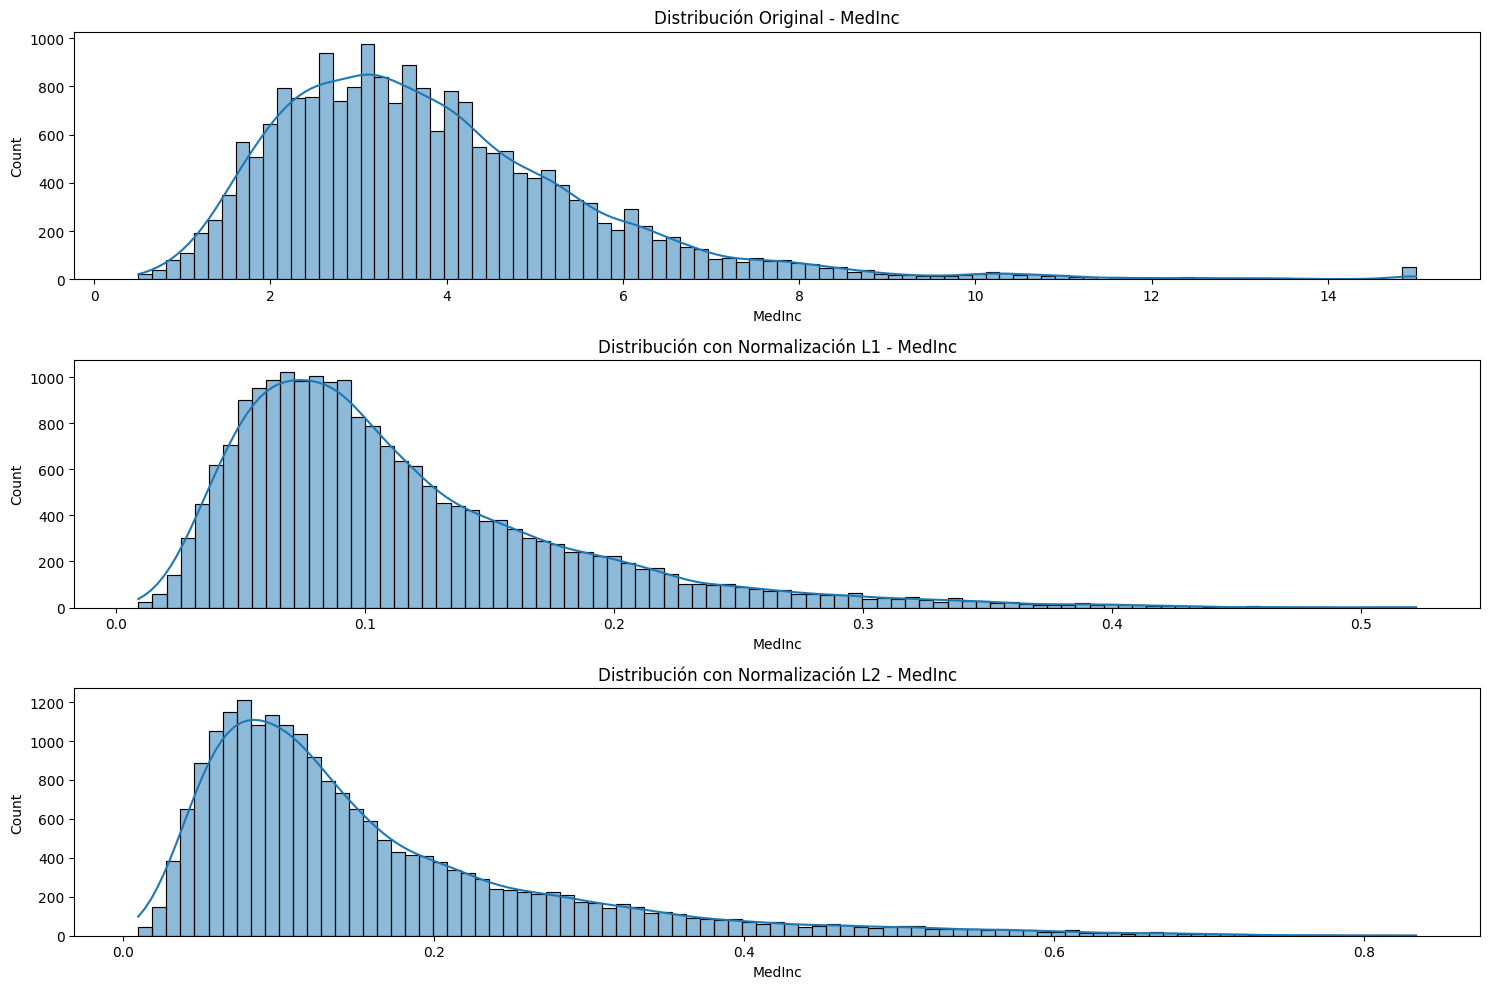

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,10))

# Original
plt.subplot(3,1,1)
sns.histplot(df_selected["MedInc"], kde=True)
plt.title("Distribución Original - MedInc")

# L1
plt.subplot(3,1,2)
sns.histplot(df_l1["MedInc"], kde=True)
plt.title("Distribución con Normalización L1 - MedInc")

# L2
plt.subplot(3,1,3)
sns.histplot(df_l2["MedInc"], kde=True)
plt.title("Distribución con Normalización L2 - MedInc")

plt.tight_layout()
plt.show()

##**6. Interpretación**
L1 y L2 normalizan los datos por fila, por lo que cada valor depende de las demás variables del mismo registro. Aun así, al graficar una columna, se observa que las distribuciones mantienen una forma similar porque el orden relativo de los datos no cambia completamente. En las gráficas, L1 concentra más los valores, mientras que L2 los mantiene un poco más dispersos. En este caso, L2 se asemeja más a la distribución original.

# <span style="color:#2F749F;"><strong>Ejercicio 4: Comparación de transformaciones para reducir asimetría</strong></span>

A partir de un conjunto de datos real sobre **pacientes con diabetes**, analiza cómo cambian las distribuciones de algunas variables clínicas al aplicar diferentes **transformaciones matemáticas utilizadas para reducir la asimetría (skewness) o estabilizar la varianza**.

1. Carga el conjunto de datos **diabetes** desde la librería `sklearn.datasets` usando `load_diabetes()`.

2. Convierte el conjunto de datos en un **DataFrame de pandas** e identifica las variables disponibles.

3. Selecciona al menos **dos variables numéricas** para el análisis (por ejemplo: `bmi`, `bp` o `s5`).

4. Aplica las siguientes **transformaciones** sobre una de las variables seleccionadas:

   - **Transformación logarítmica** usando `np.log()` o `np.log1p()`
   - **Transformación logarítmica reflejada** (útil cuando existe asimetría negativa)
   - **Transformación cuadrática** usando `x²`
   - **Transformación Box-Cox** usando `scipy.stats.boxcox`

5. Genera **gráficas comparativas** que permitan visualizar la distribución de la variable en los siguientes escenarios:
   - Distribución **original**
   - Distribución con **transformación log**
   - Distribución con **log reflejado**
   - Distribución con **transformación cuadrática**
   - Distribución con **transformación Box-Cox**

6. Escribe un análisis de **máximo cinco líneas** en el que expliques las diferencias entre las técnicas o métodos, su impacto en los resultados y cuál consideras más recomendable, justificando brevemente tu elección.

##**1. Cargar datos**

In [1]:
from sklearn.datasets import load_diabetes

# Cargar dataset
diabetes = load_diabetes()

##**2.DataFrame**

In [2]:
import pandas as pd

# Convertir a DataFrame
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)

# Ver primeras filas
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [3]:
# Mostrar nombres de variables
print(df.columns)

Index(['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6'], dtype='object')


##**3. Selección de variables**
Se seleccionarán ***"bmi" y "bp"***

In [4]:
variables = ['bmi', 'bp']
df_sel = df[variables].copy()

print("=" * 50)
print("DATOS ORIGINALES - VARIABLES SELECCIONADAS")
print("=" * 50)
print(df_sel.head(10))

print("\nEstadísticas:")
print(df_sel.describe().round(4))

DATOS ORIGINALES - VARIABLES SELECCIONADAS
        bmi        bp
0  0.061696  0.021872
1 -0.051474 -0.026328
2  0.044451 -0.005670
3 -0.011595 -0.036656
4 -0.036385  0.021872
5 -0.040696 -0.019442
6 -0.047163 -0.015999
7 -0.001895  0.066629
8  0.061696 -0.040099
9  0.039062 -0.033213

Estadísticas:
            bmi        bp
count  442.0000  442.0000
mean    -0.0000   -0.0000
std      0.0476    0.0476
min     -0.0903   -0.1124
25%     -0.0342   -0.0367
50%     -0.0073   -0.0057
75%      0.0312    0.0356
max      0.1706    0.1320


**Interpretación:**
Las variables seleccionadas muestran comportamientos distintos en sus valores.
En general, los datos están centrados cerca de cero, con una dispersión moderada.Se observan diferencias entre los valores mínimos y máximos, lo que indica variabilidad en los datos. La variable bmi presenta un rango más amplio, mientras que bp es un poco más estable.

##**4. Métodos para transformar**

Se escogerá ***"bmi"***

In [6]:
import numpy as np
from scipy.stats import skew, kurtosis

print("=" * 50)
print("VARIABLE ORIGINAL (bmi)")
print("=" * 50)

original = df['bmi']

df_original = pd.DataFrame({'Original': original})

print(df_original.head(10))

print("\nEstadísticas:")
print(df_original.describe().round(4))

print("\nSkewness:", round(skew(original),4))
print("Kurtosis:", round(kurtosis(original),4))

VARIABLE ORIGINAL (bmi)
   Original
0  0.061696
1 -0.051474
2  0.044451
3 -0.011595
4 -0.036385
5 -0.040696
6 -0.047163
7 -0.001895
8  0.061696
9  0.039062

Estadísticas:
       Original
count  442.0000
mean    -0.0000
std      0.0476
min     -0.0903
25%     -0.0342
50%     -0.0073
75%      0.0312
max      0.1706

Skewness: 0.5961
Kurtosis: 0.0805


###**Transformación logarítmica**

In [7]:
print("\n" + "=" * 50)
print("TRANSFORMACIÓN LOG")
print("=" * 50)

log_bmi = np.log1p(original)

df_log = pd.DataFrame({'Log': log_bmi})

print(df_log.head(10))

print("\nEstadísticas:")
print(df_log.describe().round(4))

print("\nSkewness:", round(skew(log_bmi),4))
print("Kurtosis:", round(kurtosis(log_bmi),4))


TRANSFORMACIÓN LOG
        Log
0  0.059868
1 -0.052846
2  0.043492
3 -0.011663
4 -0.037063
5 -0.041547
6 -0.048311
7 -0.001897
8  0.059868
9  0.038319

Estadísticas:
            Log
count  442.0000
mean    -0.0011
std      0.0471
min     -0.0946
25%     -0.0348
50%     -0.0073
75%      0.0308
max      0.1575

Skewness: 0.4783
Kurtosis: -0.1346


**Interpretación:**
La transformación log reduce la escala de los datos, haciendo que los valores sean más compactos. Se observa una menor dispersión y una distribución más controlada.

###**Transformación logarítmica reflejada**

In [54]:
print("\n" + "=" * 50)
print("TRANSFORMACIÓN LOG REFLEJADO")
print("=" * 50)

reflected = np.max(original) - original + 1
log_ref = np.log(reflected)

df_ref = pd.DataFrame({'Log_Reflejado': log_ref})

print(df_ref.head(10))

print("\nEstadísticas:")
print(df_ref.describe().round(4))

print("\nSkewness:", round(skew(log_ref),4))
print("Kurtosis:", round(kurtosis(log_ref),4))


TRANSFORMACIÓN LOG REFLEJADO
   Log_Reflejado
0       0.103332
1       0.200513
2       0.118764
3       0.167335
4       0.188088
5       0.191654
6       0.196979
7       0.159096
8       0.103332
9       0.123538

Estadísticas:
       Log_Reflejado
count       442.0000
mean          0.1566
std           0.0413
min           0.0000
25%           0.1304
50%           0.1637
75%           0.1863
max           0.2318

Skewness: -0.7066
Kurtosis: 0.3341


**Interpretación:**
Esta transformación ajusta los datos invirtiendo su comportamiento antes de aplicar el log. Los valores quedan más concentrados, aunque cambia la interpretación de la variable.

###**Transformación cuadrática**

In [55]:
print("\n" + "=" * 50)
print("TRANSFORMACIÓN CUADRÁTICA")
print("=" * 50)

square = original ** 2

df_sq = pd.DataFrame({'Cuadratica': square})

print(df_sq.head(10))

print("\nEstadísticas:")
print(df_sq.describe().round(4))

print("\nSkewness:", round(skew(square),4))
print("Kurtosis:", round(kurtosis(square),4))


TRANSFORMACIÓN CUADRÁTICA
   Cuadratica
0    0.003806
1    0.002650
2    0.001976
3    0.000134
4    0.001324
5    0.001656
6    0.002224
7    0.000004
8    0.003806
9    0.001526

Estadísticas:
       Cuadratica
count    442.0000
mean       0.0023
std        0.0033
min        0.0000
25%        0.0003
50%        0.0011
75%        0.0032
max        0.0291

Skewness: 3.5916
Kurtosis: 19.3375


**Interpretación:**
Al elevar al cuadrado, los valores grandes se amplifican, aumentando notablemente la dispersión. Esto hace que los extremos tengan más peso en la distribución.

###**Transformación Box-Cox**

In [56]:
from scipy.stats import boxcox

print("\n" + "=" * 50)
print("TRANSFORMACIÓN BOX-COX")
print("=" * 50)

bmi_positive = original - original.min() + 1
boxcox_bmi, lambda_val = boxcox(bmi_positive)

df_box = pd.DataFrame({'BoxCox': boxcox_bmi})

print(df_box.head(10))

print("\nLambda:", round(lambda_val,4))

print("\nEstadísticas:")
print(df_box.describe().round(4))

print("\nSkewness:", round(skew(boxcox_bmi),4))
print("Kurtosis:", round(kurtosis(boxcox_bmi),4))


TRANSFORMACIÓN BOX-COX
     BoxCox
0  0.104255
1  0.034947
2  0.096064
3  0.064044
4  0.046680
5  0.043423
6  0.038395
7  0.070254
8  0.104255
9  0.093360

Lambda: -4.56

Estadísticas:
         BoxCox
count  442.0000
mean     0.0680
std      0.0286
min      0.0000
25%      0.0483
50%      0.0668
75%      0.0893
max      0.1431

Skewness: 0.0368
Kurtosis: -0.5498


**Interpretación:**
La transformación Box-Cox ajusta automáticamente la escala de los datos, logrando una distribución más equilibrada. Los valores quedan mejor distribuidos en comparación con otras transformaciones.

##**5. Gráficas comparativas**

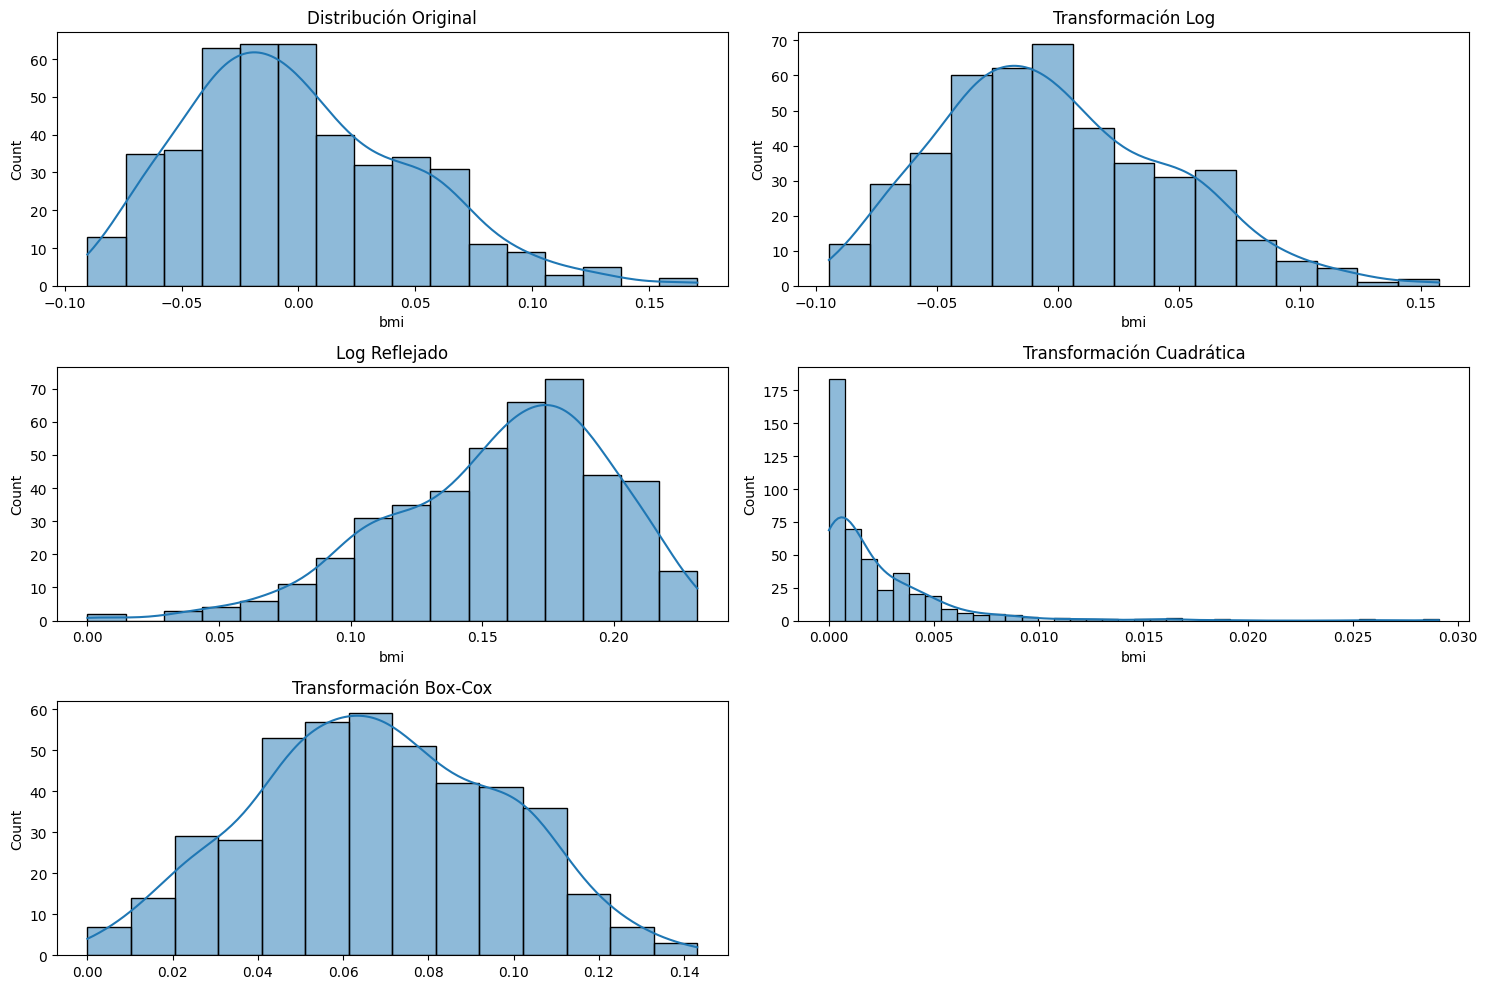

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,10))

# Original
plt.subplot(3,2,1)
sns.histplot(variable, kde=True)
plt.title("Distribución Original")

# Log
plt.subplot(3,2,2)
sns.histplot(log_bmi, kde=True)
plt.title("Transformación Log")

# Log reflejado
plt.subplot(3,2,3)
sns.histplot(log_reflected_bmi, kde=True)
plt.title("Log Reflejado")

# Cuadrática
plt.subplot(3,2,4)
sns.histplot(square, kde=True)
plt.title("Transformación Cuadrática")

# Box-Cox
plt.subplot(3,2,5)
sns.histplot(boxcox_bmi, kde=True)
plt.title("Transformación Box-Cox")

plt.tight_layout()
plt.show()

##**6. Interpretación**
En las gráficas se observa que la transformación log y Box-Cox hacen la distribución más uniforme y menos dispersa. La transformación cuadrática aumenta la concentración en valores altos, generando mayor desequilibrio visual. El log reflejado cambia la forma de la distribución, pero puede dificultar la interpretación. En general, Box-Cox es la más recomendable porque logra un mejor equilibrio en la distribución sin distorsionar demasiado los datos.

#<span style="color:#2F749F;"><strong>Ejercicio 5: Comparación de transformaciones para reducir asimetría</strong></span>

A partir de un conjunto de datos real sobre **pacientes con enfermedades cardíacas**, analiza cómo cambian las distribuciones de algunas variables clínicas al aplicar diferentes **transformaciones matemáticas utilizadas para reducir la asimetría (skewness) o estabilizar la varianza**.

1. Carga el conjunto de datos **Heart Disease** desde la librería `ucimlrepo` usando `load_dataset("heart_disease = fetch_ucirepo(id=45)")`.

2. Convierte el conjunto de datos en un **DataFrame de pandas** e identifica las variables disponibles.

3. Selecciona al menos **dos variables numéricas** para el análisis (por ejemplo:  
   - `chol` (colesterol)  
   - `trestbps` (presión arterial en reposo)  
   - `thalach` (frecuencia cardíaca máxima)).

4. Aplica las siguientes **transformaciones** sobre una de las variables seleccionadas:

   - **Raíz cuadrada** usando `np.sqrt()`  
   - **Recíproca** usando `1/x`  
   - **Transformación Yeo-Johnson** usando `PowerTransformer(method="yeo-johnson")`

5. Genera **gráficas comparativas** que permitan visualizar la distribución de la variable en los siguientes escenarios:
   - Distribución **original**
   - Distribución con **transformación raíz cuadrada**
   - Distribución con **transformación recíproca**
   - Distribución con **transformación Yeo-Johnson**

6. Escribe un análisis de **máximo cinco líneas** en el que expliques las diferencias entre las técnicas o métodos, su impacto en los resultados y cuál consideras más recomendable, justificando brevemente tu elección.

##**1. Cargar datos**

In [19]:
!pip install ucimlrepo

from ucimlrepo import fetch_ucirepo

# Cargar dataset Heart Disease
heart_disease = fetch_ucirepo(id=45)

##**2. DataFrame**

In [20]:
import pandas as pd

# Convertir a DataFrame
df = heart_disease.data.features
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0


In [21]:
# Ver nombres de variables
print("\nVariables disponibles:")
print(df.columns.tolist())


Variables disponibles:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


##**3. Selección de variables**
Se seleccionaron ***"chol"*** y ***"trestbps"***

In [22]:
# Seleccionar variables
variables = ["chol", "trestbps"]

df_selected = df[variables].copy()

print("=" * 50)
print("VARIABLES SELECCIONADAS")
print("=" * 50)
print(df_selected.head())

print("\nEstadísticas:")
print(df_selected.describe().round(4))

VARIABLES SELECCIONADAS
   chol  trestbps
0   233       145
1   286       160
2   229       120
3   250       130
4   204       130

Estadísticas:
           chol  trestbps
count  303.0000  303.0000
mean   246.6931  131.6898
std     51.7769   17.5997
min    126.0000   94.0000
25%    211.0000  120.0000
50%    241.0000  130.0000
75%    275.0000  140.0000
max    564.0000  200.0000


**Interpretación**
Las variables muestran comportamientos distintos en sus estadísticas. chol presenta alta dispersión con valores muy separados, trestbps es más estable y concentrada alrededor de la media, y thalach tiene una dispersión intermedia, siendo más equilibrada entre las tres.

##**4. Transformaciones**

###**Transformación raíz cuadrada**

In [23]:
df_sqrt = pd.DataFrame()
df_sqrt['chol'] = np.sqrt(df_selected['chol'])

print("=" * 50)
print("RAÍZ CUADRADA")
print("=" * 50)
print(df_sqrt.head())

print("\nEstadísticas:")
print(df_sqrt.describe().round(4))

RAÍZ CUADRADA
        chol
0  15.264338
1  16.911535
2  15.132746
3  15.811388
4  14.282857

Estadísticas:
           chol
count  303.0000
mean    15.6246
std      1.6043
min     11.2250
25%     14.5258
50%     15.5242
75%     16.5831
max     23.7487


**Interpretación:**
Reduce la magnitud de los valores, baja la dispersión y hace que los datos queden un poco más compactos.

###**Transformación recíproca (1/x)**

In [24]:
df_recip = pd.DataFrame()
df_recip['chol'] = 1 / df_selected['chol']

print("=" * 50)
print("RECÍPROCA (1/x)")
print("=" * 50)
print(df_recip.head())

print("\nEstadísticas:")
print(df_recip.describe().round(4))

RECÍPROCA (1/x)
       chol
0  0.004292
1  0.003497
2  0.004367
3  0.004000
4  0.004902

Estadísticas:
           chol
count  303.0000
mean     0.0042
std      0.0009
min      0.0018
25%      0.0036
50%      0.0041
75%      0.0047
max      0.0079


**Interpretación:**
Cambia completamente la escala, los valores se vuelven muy pequeños y la dispersión se reduce bastante.

###**Transformación Yeo-Johnson**

In [25]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson')

df_yeojohnson = pd.DataFrame(
    pt.fit_transform(df_selected[['chol']]),
    columns=['chol']
)

print("=" * 50)
print("YEO-JOHNSON")
print("=" * 50)
print(df_yeojohnson.head())

print("\nEstadísticas:")
print(df_yeojohnson.describe().round(4))

YEO-JOHNSON
       chol
0 -0.169500
1  0.833883
2 -0.255179
3  0.177487
4 -0.830793

Estadísticas:
           chol
count  303.0000
mean     0.0000
std      1.0017
min     -3.2984
25%     -0.6621
50%     -0.0029
75%      0.6434
max      4.0198


**Interpretación:**
Ajusta los datos sin cambiar drásticamente la escala, deja los valores más centrados y con una dispersión más equilibrada.

##**Gráficas comparativas**

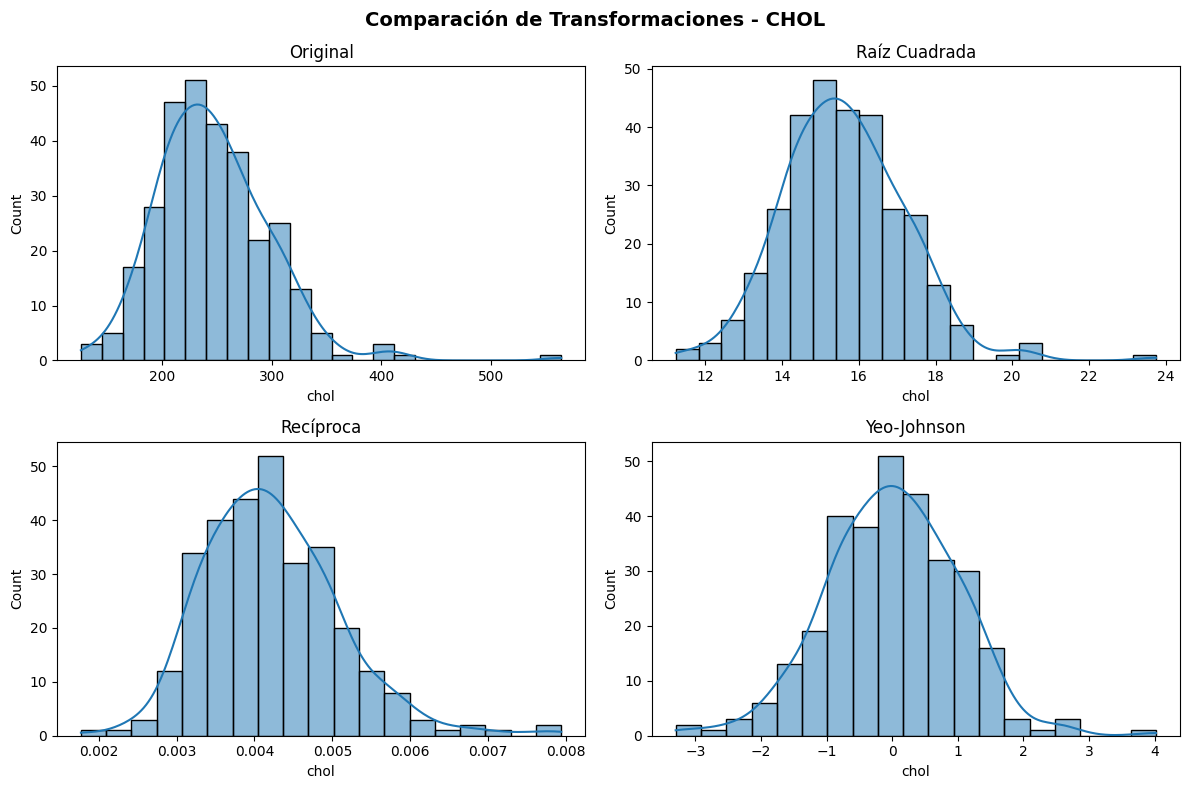

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Comparación de Transformaciones - CHOL', fontsize=14, fontweight='bold')

sns.histplot(df_selected['chol'], kde=True, ax=axes[0,0])
axes[0,0].set_title('Original')

sns.histplot(df_sqrt['chol'], kde=True, ax=axes[0,1])
axes[0,1].set_title('Raíz Cuadrada')

sns.histplot(df_recip['chol'], kde=True, ax=axes[1,0])
axes[1,0].set_title('Recíproca')

sns.histplot(df_yeojohnson['chol'], kde=True, ax=axes[1,1])
axes[1,1].set_title('Yeo-Johnson')

plt.tight_layout()
plt.show()

##**6. Interpretación**
Las gráficas muestran que cada transformación cambia la forma de la distribución de manera distinta. La raíz cuadrada suaviza un poco la dispersión, mientras que la recíproca la reduce demasiado y deforma la escala. Yeo-Johnson logra una distribución más equilibrada sin distorsionar tanto los datos. En general, Yeo-Johnson es la más recomendable porque mejora la forma de la distribución manteniendo coherencia en los valores.